# RQ4: How does feature engineering (e.g., polynomial features) affect model prediction accuracy?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Regression with Feature Engineering

In [1]:
# ── Imports ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded ")

Libraries loaded 


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

# reduce size (important)
if len(df) > 80000:
    df = df.sample(80000, random_state=42).reset_index(drop=True)

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# ── Scaling ─────────────────────────

scaler = StandardScaler()

X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

In [5]:
# ── Baseline Model ─────────────────────────

lr = LinearRegression()
lr.fit(X_tr_sc, y_train)

pred_base = lr.predict(X_te_sc)

base_mae = mean_absolute_error(y_test, pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, pred_base))
base_r2 = r2_score(y_test, pred_base)

print(f"Baseline → MAE={base_mae:.2f}, RMSE={base_rmse:.2f}, R2={base_r2:.4f}")

Baseline → MAE=16.91, RMSE=19.65, R2=0.0381


In [6]:
# ── Feature Engineering ─────────────────────────

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_tr_sc)
X_test_poly = poly.transform(X_te_sc)

print("Original features:", X_tr_sc.shape)
print("After polynomial:", X_train_poly.shape)

Original features: (64000, 11)
After polynomial: (64000, 77)


In [7]:
# ── Model with Feature Engineering ─────────────────

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

pred_poly = lr_poly.predict(X_test_poly)

poly_mae = mean_absolute_error(y_test, pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, pred_poly))
poly_r2 = r2_score(y_test, pred_poly)

print(f"With FE → MAE={poly_mae:.2f}, RMSE={poly_rmse:.2f}, R2={poly_r2:.4f}")

With FE → MAE=16.60, RMSE=19.38, R2=0.0644


In [8]:
# ── Table 4.1 ─────────────────────────

results = pd.DataFrame({
    "Model": ["Baseline", "With Feature Engineering"],
    "MAE": [base_mae, poly_mae],
    "RMSE": [base_rmse, poly_rmse],
    "R2": [base_r2, poly_r2]
})

styled = results.style\
    .format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"})\
    .set_caption("Table 4.1: Impact of Feature Engineering (RQ4)")\
    .background_gradient(cmap="Blues", subset=["MAE", "RMSE"])\
    .background_gradient(cmap="Greens", subset=["R2"])

display(styled)

,Model,MAE,RMSE,R2
0,Baseline,16.91,19.65,0.038
1,With Feature Engineering,16.60,19.38,0.064


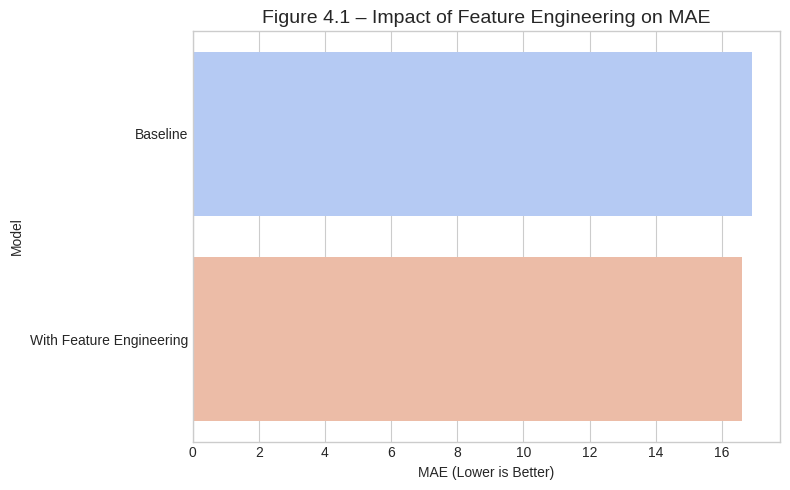

In [9]:
# ── Figure 4.1 ─────────────────────────

plt.figure(figsize=(8,5))

sns.barplot(data=results, x="MAE", y="Model", palette="coolwarm")

plt.title("Figure 4.1 – Impact of Feature Engineering on MAE", fontsize=14)
plt.xlabel("MAE (Lower is Better)")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

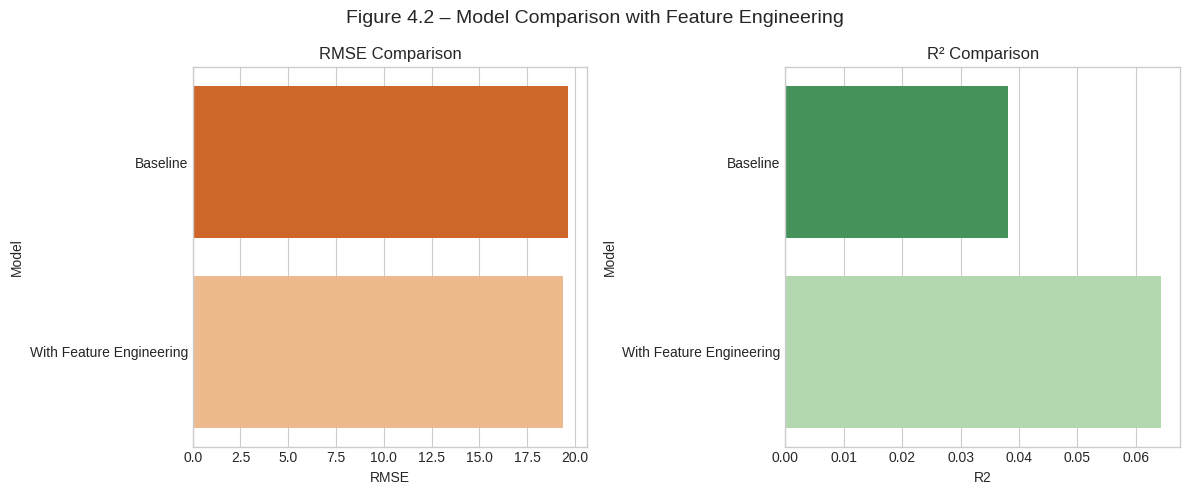

In [10]:
# ── Figure 4.2 ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(data=results, x="RMSE", y="Model", ax=axes[0], palette="Oranges_r")
axes[0].set_title("RMSE Comparison")

sns.barplot(data=results, x="R2", y="Model", ax=axes[1], palette="Greens_r")
axes[1].set_title("R² Comparison")

plt.suptitle("Figure 4.2 – Model Comparison with Feature Engineering", fontsize=14)

plt.tight_layout()
plt.show()

In [11]:
# ── Conclusion ─────────────────────────

print("Conclusion:")

if poly_mae < base_mae:
    print("Feature engineering improved model performance.")
else:
    print("Feature engineering did not significantly improve performance.")

print("Polynomial features introduce non-linear relationships which may help or hurt depending on data.")

Conclusion:
Feature engineering improved model performance.
Polynomial features introduce non-linear relationships which may help or hurt depending on data.
